<a href="https://colab.research.google.com/github/Kumkum27-byte/Payment-Recovery-Agent/blob/main/Razorpay_Buildathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Payment Recovery Agent — Razorpay Buildathon (Track 3)

A multi-agent pipeline that detects payment failures, diagnoses root cause
(temporary vs permanent), and executes a bounded recovery action — with a
full audit trail and measured recovery metrics.

**Pipeline:** Data Loader → Detector → Diagnoser → Recovery → Audit & Metrics

In [ ]:
!pip install pandas langgraph

In [ ]:
import random
import pandas as pd

In [ ]:
random.seed(42)

In [ ]:
payment_methods = ['card', 'upi', 'netbanking']
failure_reasons = ['bank_timeout', 'insufficient_balance', 'otp_timeout', 'gateway_error', 'card_declined']
merchant_ids = ['M001', 'M002', 'M003', 'M004', 'M005']
statuses = ['success', 'failed', 'degraded']

In [ ]:
# function classifying temporary vs permanent issue
def get_ground_truth(reason):
  temporary=['bank_timeout', 'gateway_error']
  return 'temporary' if reason in temporary else 'permanent'

In [ ]:
rows = []

In [ ]:
for i in range(1, 101):
  status = random.choice(statuses)

  if status == 'success':
    reason = 'none'
  else:
    reason = random.choice(failure_reasons)

  row = {
      'transaction_id' : f"TXN{i:03d}",
      'merchant_id' : random.choice(merchant_ids),
      'amount' : random.randint(100, 5000),
      'payment_method' : random.choice(payment_methods),
      'status' : status,
      'failure_reason' : reason,
      'ground_truth_type' : get_ground_truth(reason) if status != 'success' else 'none',
      'retry_count' : random.randint(0,3)
  }

  rows.append(row)

  df = pd.DataFrame(rows)
  df.to_csv('Payment_Transactions.csv', index = False)

In [ ]:
df.head()

,transaction_id,merchant_id,amount,payment_method,status,failure_reason,ground_truth_type,retry_count
0,TXN001,M001,2353,card,degraded,bank_timeout,temporary,1
1,TXN002,M001,4567,card,success,none,none,3
2,TXN003,M001,867,card,success,none,none,1
3,TXN004,M001,4697,card,degraded,card_declined,permanent,3
4,TXN005,M004,4927,upi,success,none,none,0


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Any

In [ ]:
class PipelineState(TypedDict):
  all_transactions : list[dict[str, Any]]
  flagged_transactions : list[dict[str, Any]]
  diagnosed_transactions : list[dict[str, Any]]
  recovered_transactions : list[dict[str, Any]]
  audit_log : list[dict[str, Any]]
  final_metrics : dict[str, Any]

In [ ]:
def load_data(state : PipelineState) -> PipelineState:

  state['all_transactions'] = df.to_dict('records')      #har row ek alag dictionary ban jayegi
  print(f"Data Loader: {len(state['all_transactions'])} transactions loaded")
  return state

In [ ]:
df['status'].value_counts()

,count
status,
success,43
degraded,37
failed,20


In [ ]:
def detector(state : PipelineState) -> PipelineState:
  flagged = []
  for txn in state['all_transactions']:
    if txn['status'] != 'success':
      flagged.append(txn)

  log_entries = [
      {'transaction_id' : txn['transaction_id'], 'step' : 'detector', 'note' : 'flagged as non-success'}
      for txn in flagged
  ]

  state['flagged_transactions'] = flagged
  state['audit_log'].extend(log_entries)

  print(f"Detector: {len(flagged)} out of {len(state['all_transactions'])} flagged")
  return state

In [ ]:
def diagnoser(state : PipelineState) -> PipelineState:

  temporary_reasons = ['bank_timeout', 'gateway_error']
  diagnosed = []
  log_entries = []

  for txn in state['flagged_transactions']:
    reason = txn['failure_reason']
    predicted_type = 'temporary' if reason in temporary_reasons else 'permanent'


    #simulate imperfect model : 12% chance of misclassifying
    random.seed(hash(txn['transaction_id'] + 'diag') % 1000)

    #real-world imperfection simulate krne ke liye
    if random.random()<0.12:
      predicted_type = 'permanent' if predicted_type == 'temporary' else 'temporary'
    else:
      predicted_type = predicted_type

    txn_with_diagnosis = txn.copy()
    txn_with_diagnosis['predicted_type'] = predicted_type
    diagnosed.append(txn_with_diagnosis)

    log_entries.append({
        'transaction_id' : txn['transaction_id'],
        'step' : 'diagnoser',
        'note' : f"predicted as {predicted_type} (reason : {reason})"
    })

  state['diagnosed_transactions'] = diagnosed
  state['audit_log'].extend(log_entries)

  print(f"Diagnoser : {len(diagnosed)} transactions classified")
  return state

In [ ]:
def recovery(state : PipelineState) -> PipelineState:
  recovered = []
  log_entries = []

  for txn in state['diagnosed_transactions']:
    predicted_type = txn['predicted_type']

    if predicted_type == 'temporary':
      random.seed(hash(txn['transaction_id']) % 1000)
      success = random.random() < 0.6               #60% chance retry se fix hoga
      action = 'auto-retry'
      retries_used = 1
      final_status = 'recovered' if success else 'still_failed'

    else:
      action = 'notify_customer'
      retries_used = 0
      final_status = 'pending_customer_action'

    txn_with_recovery = txn.copy()
    txn_with_recovery['action_taken'] = action
    txn_with_recovery['retries_used'] = retries_used
    txn_with_recovery['final_status'] = final_status
    recovered.append(txn_with_recovery)

    log_entries.append({
        'transaction_id' : txn['transaction_id'],
        'step' : 'recovery',
        'note' : f"action = {action}, final_status={final_status}"
    })

  state['recovered_transactions'] = recovered
  state['audit_log'].extend(log_entries)

  print(f"Recovery : {len(recovered)} transactions processed")
  return state

In [ ]:
def metrics (state : PipelineState) -> PipelineState:
  total = len(state['all_transactions'])
  flagged = len(state['flagged_transactions'])

  correct_predictions = sum(
      1 for txn in state['diagnosed_transactions']
      if txn['predicted_type'] == txn['ground_truth_type']
  )

  precision = correct_predictions /  len(state['diagnosed_transactions'])

  recovered_count = sum(
      1 for txn in state['recovered_transactions']
      if txn['final_status'] == 'recovered'
  )

  recovery_rate = recovered_count / flagged if flagged else 0

  print("-------METRICS-------")
  print(f"Total Transactions : {total}")
  print(f"Flagged (non-success) :  {flagged}")
  print(f"Diagnosed precision : {precision:.2%}")
  print(f"Recoevry rate: {recovery_rate:.2%} ({recovered_count}/{flagged})")
  print(f"Audit log entries: {len(state['audit_log'])}")

  detection_rate = flagged / total if total else 0

  state['final_metrics'] = {
      'detection_rate': detection_rate,
      'diagnosis_precision': precision,
      'recovery_rate': recovery_rate,
  }

  return state

In [ ]:
graph = StateGraph(PipelineState)

In [ ]:
graph.add_node('Synthetic Transaction Data', load_data)
graph.add_node('Detector Node', detector)
graph.add_node('Diagnoser Node', diagnoser)
graph.add_node('Recovery Node', recovery)
graph.add_node('Audit Trail & Metrics', metrics)

graph.add_edge(START, 'Synthetic Transaction Data')
graph.add_edge('Synthetic Transaction Data', 'Detector Node')
graph.add_edge('Detector Node', 'Diagnoser Node')
graph.add_edge('Diagnoser Node', 'Recovery Node')
graph.add_edge('Recovery Node', 'Audit Trail & Metrics')
graph.add_edge('Audit Trail & Metrics', END)

app = graph.compile()

In [ ]:
def fresh_state() -> PipelineState:
    return {
        'all_transactions': [],
        'flagged_transactions': [],
        'diagnosed_transactions': [],
        'recovered_transactions': [],
        'audit_log': [],
        'final_metrics' : dict[str, Any]
    }

In [ ]:
final_state = app.invoke(fresh_state())

Data Loader: 100 transactions loaded
Detector: 57 out of 100 flagged
Diagnoser : 57 transactions classified
Recovery : 57 transactions processed
-------METRICS-------
Total Transactions : 100
Flagged (non-success) :  57
Diagnosed precision : 84.21%
Recoevry rate: 21.05% (12/57)
Audit log entries: 171


In [ ]:
audit_df = pd.DataFrame(final_state['audit_log'])
audit_df.to_csv('audit_trail.csv', index = False)
audit_df

,transaction_id,step,note
0,TXN001,detector,flagged as non-success
1,TXN004,detector,flagged as non-success
2,TXN011,detector,flagged as non-success
3,TXN012,detector,flagged as non-success
4,TXN013,detector,flagged as non-success
...,...,...,...
166,TXN095,recovery,"action = auto-retry, final_status=recovered"
167,TXN096,recovery,"action = notify_customer, final_status=pending..."
168,TXN097,recovery,"action = auto-retry, final_status=still_failed"
169,TXN098,recovery,"action = auto-retry, final_status=still_failed"


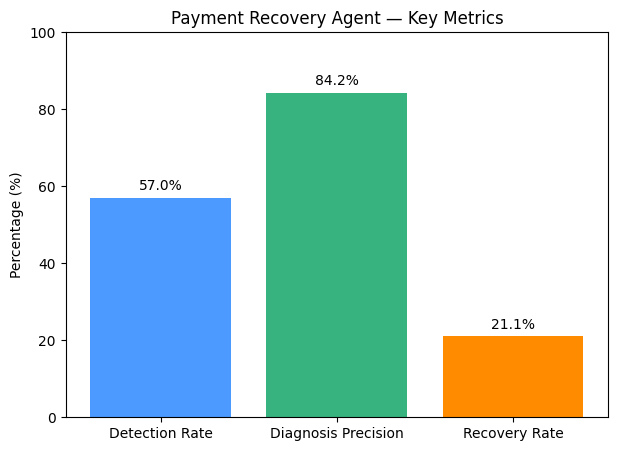

In [ ]:
import matplotlib.pyplot as plt

m = final_state['final_metrics']
labels = ['Detection Rate', 'Diagnosis Precision', 'Recovery Rate']
values = [m['detection_rate'] * 100, m['diagnosis_precision'] * 100, m['recovery_rate'] * 100]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=['#4C9AFF', '#36B37E', '#FF8B00'])
plt.ylabel('Percentage (%)')
plt.title('Payment Recovery Agent — Key Metrics')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.savefig('metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()